In [1]:
#!conda env list

In [2]:
#!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# Cell 1: Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# Allow OGR to accept non-closed rings
os.environ["OGR_GEOMETRY_ACCEPT_UNCLOSED_RING"] = "YES"

# --- Configuration ---
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"  # UTM Zone 15
tornado_csv = "/home/njm12/ATMS_596/1950-2024_actual_tornadoes.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]
min_date = pd.to_datetime("1950-01-01")  # Start from first date in dataset

In [5]:
# Cell 2: Load UMESC Mississippi River shapefiles
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]
gdfs = []

for pool_dir in pool_dirs:
    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        local_crs = "EPSG:26916"
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        local_crs = target_crs

    for f in shp_files:
        gdf = gpd.read_file(f)
        if gdf.crs is None:
            gdf = gdf.set_crs(local_crs)
        gdf = gdf.to_crs(target_crs)
        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)
print("UMESC combined:", umesc_all.shape)
print(f"Pools included: {sorted(umesc_all['POOL'].unique())}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/njm12/ATMS_523/envs/xarray-climate/share/proj failed


UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']


In [6]:
# --- Derive approximate river centerline from UMESC polygons ---
# Fix invalid polygons before union
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)  # Ensures clean geometry

# Use the new 'union_all()' method (replaces deprecated unary_union)
river_union = umesc_all.union_all()

# Derive approximate river centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)
print("River centerline constructed from UMESC polygons.")

River centerline constructed from UMESC polygons.


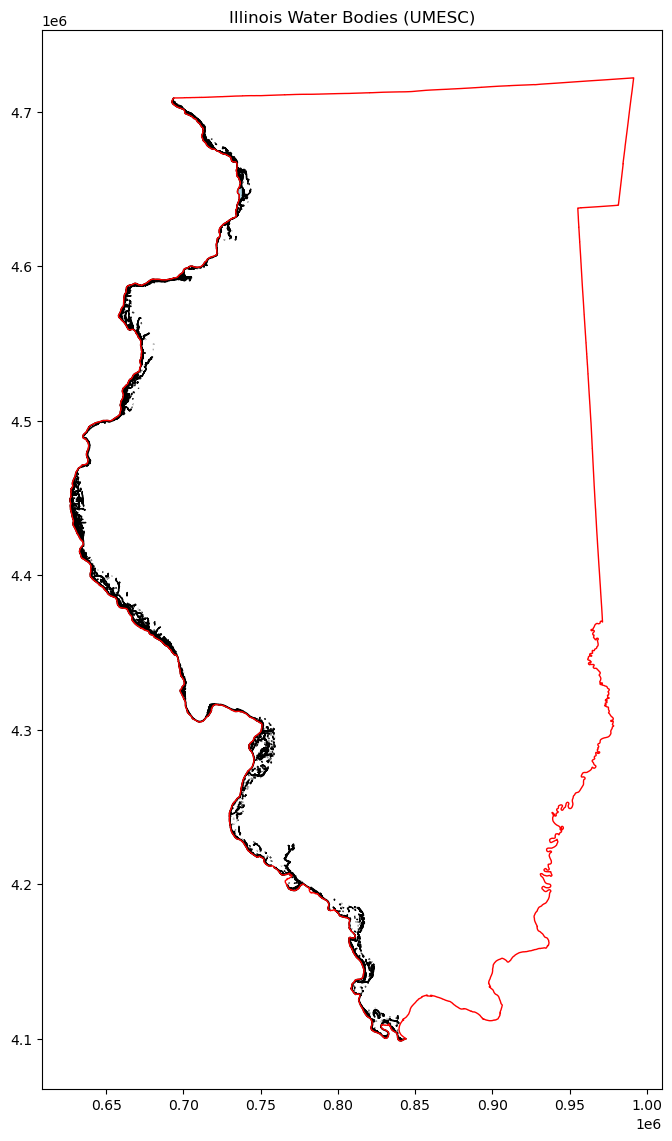

In [7]:
# Cell 3: Extract Illinois water portion
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)
illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

# Filter water polygons only
water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()
water_il = gpd.clip(water_only, illinois)

# Plot check
ax = water_il.plot(figsize=(8, 14), color="lightblue", edgecolor="k")
illinois.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Illinois Water Bodies (UMESC)")
plt.show()

In [8]:
print("Number of invalid geometries in water_only:", (~water_only.is_valid).sum())
print("Invalid geometries indices:", water_only[~water_only.is_valid].index)

Number of invalid geometries in water_only: 0
Invalid geometries indices: Index([], dtype='int64')


In [9]:
# Fix invalid geometries using buffer(0) - only if needed
water_only.loc[~water_only.is_valid, "geometry"] = water_only.loc[~water_only.is_valid, "geometry"].buffer(0)

# Verify
print("Invalid geometries after fix:", (~water_only.is_valid).sum())

Invalid geometries after fix: 0


In [10]:
# Ensure Illinois geometry is valid
illinois["geometry"] = illinois["geometry"].buffer(0)

# Perform clip
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

Clipped water shapes: (2876, 14)


In [11]:
# Combine all Illinois water polygons into a single geometry
river_il = water_il.union_all()
print(type(river_il))
print("Bounds of Illinois river section:", river_il.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Bounds of Illinois river section: (626594.3664122473, 4098437.22724262, 844182.0029604747, 4708927.272888837)


In [12]:
# Automatic date parsing
tornadoes = pd.read_csv(tornado_csv, parse_dates=['date'])

# Filter by states, EF-scale, and date (can include stronger tornadoes on map, if necessary / min_date will likely be changed)
tornadoes = tornadoes[
    tornadoes['st'].isin(states_of_interest) &
    tornadoes['mag'].isin([0, 1, 2, 3, 4, 5]) &
    (tornadoes['date'] >= min_date)
]

print("Filtered tornadoes:", tornadoes.shape)
tornadoes

Filtered tornadoes: (8287, 29)


,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
6,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,18.80,50,1,1,1,119,117,0,0,0
7,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,18.00,200,1,1,1,119,5,0,0,0
9,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,9.60,50,1,1,1,157,0,0,0,0
11,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,2.30,300,1,1,1,93,0,0,0,0
12,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,0.10,100,1,1,1,91,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71664,624857,2024,8,15,2024-08-15,22:06:00,3,IL,17,0,...,3.20,50,1,1,1,175,0,0,0,0
71687,624880,2024,8,30,2024-08-30,11:45:00,3,IL,17,0,...,0.08,20,1,1,1,157,0,0,0,0
71712,624820,2024,8,5,2024-08-05,20:57:00,3,IA,19,0,...,0.33,30,1,1,1,191,0,0,0,0
71713,624821,2024,8,5,2024-08-05,21:11:00,3,IA,19,0,...,0.98,80,1,1,1,191,0,0,0,0


In [13]:
# Remove any rows with missing or invalid coordinates
coord_cols = ['slon', 'slat', 'elon', 'elat']
tornadoes = tornadoes.dropna(subset=coord_cols)

# Remove out-of-bounds or unrealistic coordinates
tornadoes = tornadoes[
    (tornadoes['slon'].between(-180, 180)) &
    (tornadoes['elon'].between(-180, 180)) &
    (tornadoes['slat'].between(-90, 90)) &
    (tornadoes['elat'].between(-90, 90))
]
print("After coordinate cleaning:", tornadoes.shape)

After coordinate cleaning: (8287, 29)


In [14]:
# --- Fix 1: Convert positive longitudes (U.S. longitudes are negative west of Greenwich) ---
tornadoes['slon'] = tornadoes['slon'].apply(lambda x: -x if x > 0 else x)
tornadoes['elon'] = tornadoes['elon'].apply(lambda x: -x if x > 0 else x)

# --- Fix 2: Remove zero or missing coordinates (invalid positions) ---
tornadoes.loc[tornadoes['slat'] == 0, 'slat'] = np.nan
tornadoes.loc[tornadoes['elat'] == 0, 'elat'] = np.nan
tornadoes.loc[tornadoes['slon'] == 0, 'slon'] = np.nan
tornadoes.loc[tornadoes['elon'] == 0, 'elon'] = np.nan

# Drop rows with NaNs after cleaning
tornadoes = tornadoes.dropna(subset=['slon', 'slat', 'elon', 'elat']).copy()

# Check coordinate ranges again
print("Longitude range (fixed):", tornadoes[['slon', 'elon']].min().min(), "to", tornadoes[['slon', 'elon']].max().max())
print("Latitude range (fixed):", tornadoes[['slat', 'elat']].min().min(), "to", tornadoes[['slat', 'elat']].max().max())

Longitude range (fixed): -96.6 to -85.23
Latitude range (fixed): 36.0022 to 45.5


In [15]:
from shapely.geometry import LineString, Point
import geopandas as gpd

# Create LineString or Point geometries
def make_geom(row):
    if pd.isna(row['elon']) or pd.isna(row['elat']) or \
       (row['elon'] == row['slon'] and row['elat'] == row['slat']):
        return Point(row['slon'], row['slat'])
    else:
        return LineString([(row['slon'], row['slat']), (row['elon'], row['elat'])])

tornadoes['geometry'] = tornadoes.apply(make_geom, axis=1)

# Convert to GeoDataFrame
tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry='geometry', crs="EPSG:4326")

# Reproject to match water shapefile CRS
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado geometries rebuilt")
print("Geometry types:", tornado_gdf.geometry.geom_type.value_counts())
print("Bounds:", tornado_gdf.total_bounds)

Tornado geometries rebuilt
Geometry types: LineString    4739
Point         1054
Name: count, dtype: int64
Bounds: [ 205367.62901075 3987738.95756939 1160467.39964418 5041734.47457036]


In [16]:
# Fix invalid water polygons
water_il['geometry'] = water_il['geometry'].buffer(0)

# Merge into single geometry
river_il_geom = water_il.geometry.union_all()  # or .union_all() if using new shapely

# Ensure the final geometry is valid
from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

In [17]:
# Buffer by 10 km
river_buffer = river_il_geom.buffer(10000)  # adjust as needed

# Check intersections with buffer
tornado_gdf['crosses_river'] = tornado_gdf.intersects(river_buffer)
crossings = tornado_gdf[tornado_gdf['crosses_river']]

print("Total tornadoes crossing Mississippi River or intersecting buffered zone:", crossings.shape[0])
print("Counts by EF-scale:\n", crossings['mag'].value_counts())

Total tornadoes crossing Mississippi River or intersecting buffered zone: 372
Counts by EF-scale:
 mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [18]:
#Quick sanity check to make sure the river buffer is actually or approximately ~10 km (and in the right units). 

from shapely.ops import nearest_points

# Pick a point on the river geometry
river_point = river_il_geom.representative_point()

# Pick nearest point on the buffer boundary
buffer_boundary = river_buffer.boundary
nearest = nearest_points(river_point, buffer_boundary)[1]

# Compute distance in meters (UTM units)
distance_m = river_point.distance(nearest)
distance_km = distance_m / 1000
print(f"Distance from river to buffer boundary: {distance_km:.2f} km")

Distance from river to buffer boundary: 10.67 km


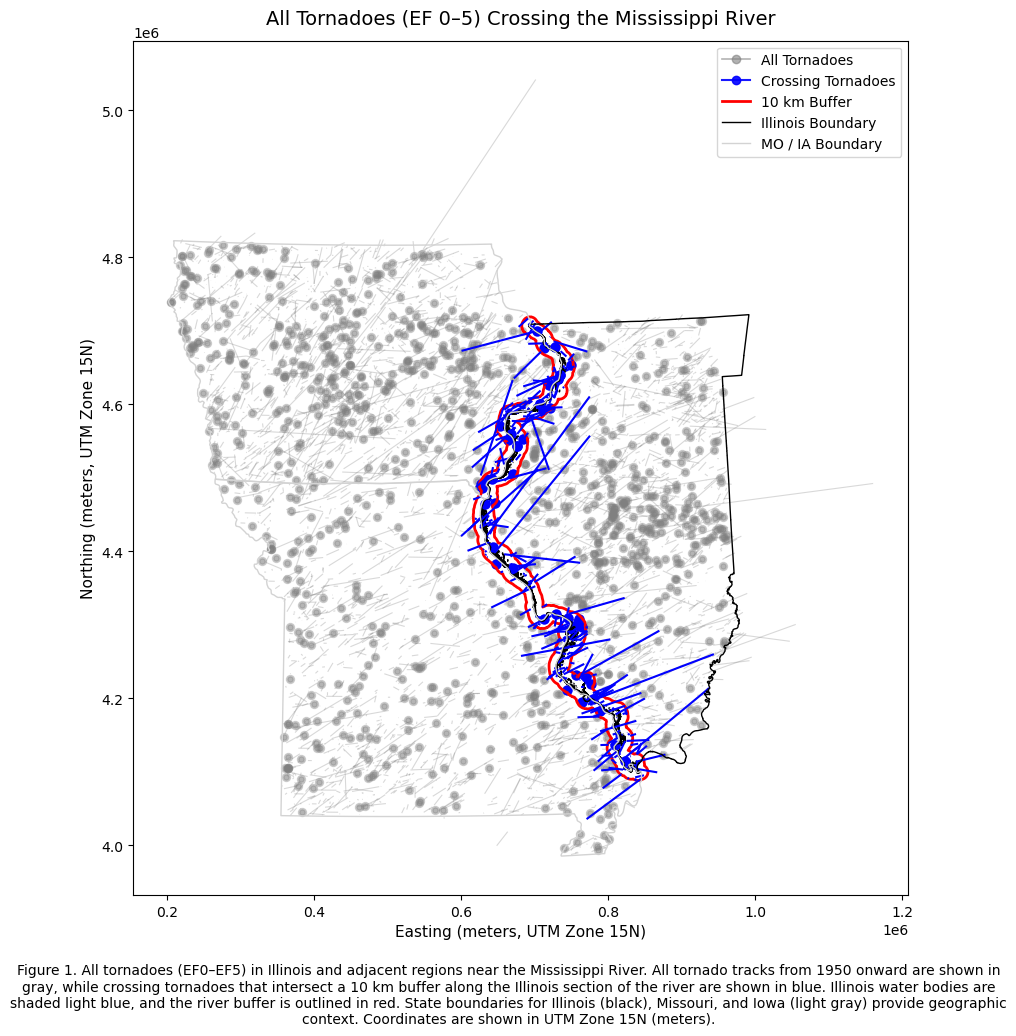

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(10, 14))

# Plot Illinois water and river buffer
water_il.plot(ax=ax, color='lightblue', edgecolor='k')
gpd.GeoSeries([river_buffer]).boundary.plot(ax=ax, color='red', linewidth=2, label='10 km Buffer')

# Plot all tornadoes (lines + points)
tornado_gdf.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3)
tornado_gdf[tornado_gdf.geometry.geom_type == 'Point'].plot(ax=ax, color='gray', markersize=15, alpha=0.4)

# Plot crossing tornadoes (lines + points)
crossings.plot(ax=ax, color='blue', linewidth=1.5)
crossings[crossings.geometry.geom_type == 'Point'].plot(ax=ax, color='blue', markersize=25)

# Plot Illinois, Missouri, and Iowa boundaries
illinois.boundary.plot(ax=ax, color='black', linewidth=1, label='Illinois Boundary')

states_path = "/home/njm12/ATMS_596/ne_10m_admin_1_states_provinces.shp"
states = gpd.read_file(states_path).to_crs(target_crs)
states_mo_ia = states[states['name'].isin(['Missouri', 'Iowa'])]
states_mo_ia.boundary.plot(ax=ax, color='lightgray', linewidth=1, label='MO / IA Boundary')

# --- Custom legend handles (combined line + point) ---
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
           label='All Tornadoes', alpha=0.6),
    Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
           label='Crossing Tornadoes', alpha=0.9),
    Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
    Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
]

# --- Labels, title, and caption ---
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
ax.set_xlabel("Easting (meters, UTM Zone 15N)", fontsize=11)
ax.set_ylabel("Northing (meters, UTM Zone 15N)", fontsize=11)

# Figure caption
caption = (
    "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
    "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
    "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
    "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
    "provide geographic context. Coordinates are shown in UTM Zone 15N (meters)."
)
plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()

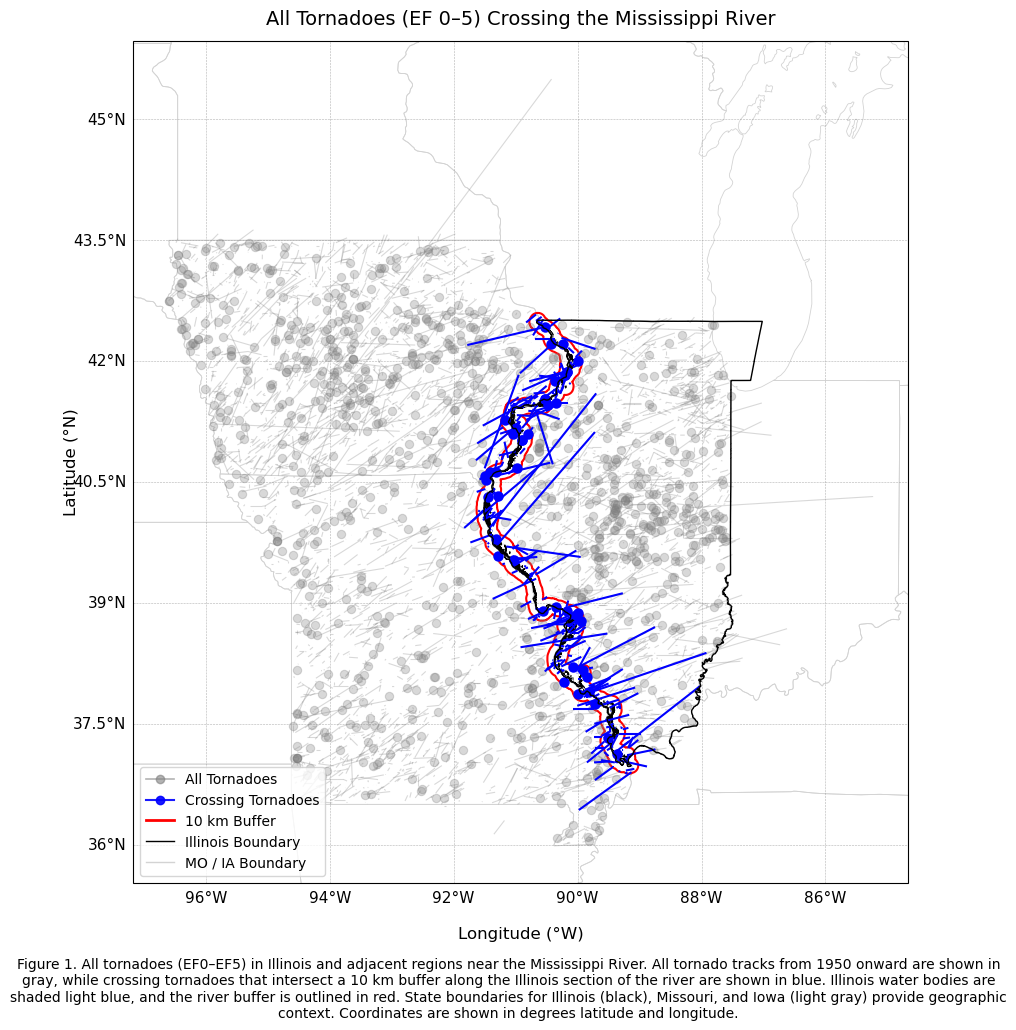

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reproject all layers to geographic (EPSG:4326)
tornado_geo = tornado_gdf.to_crs("EPSG:4326")
crossings_geo = crossings.to_crs("EPSG:4326")
water_il_geo = water_il.to_crs("EPSG:4326")
illinois_geo = illinois.to_crs("EPSG:4326")
river_buffer_geo = gpd.GeoSeries([river_buffer], crs=water_il.crs).to_crs("EPSG:4326")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map background
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.6)

# Plot layers
water_il_geo.plot(ax=ax, color='lightblue', edgecolor='k', transform=ccrs.PlateCarree(), zorder=1)
river_buffer_geo.boundary.plot(ax=ax, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), label='10 km Buffer', zorder=2)
tornado_geo.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3, transform=ccrs.PlateCarree(), label='All Tornadoes', zorder=3)
crossings_geo.plot(ax=ax, color='blue', linewidth=1.5, transform=ccrs.PlateCarree(), label='Crossing Tornadoes', zorder=4)
illinois_geo.boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

# Gridlines and coordinate labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Add axis labels manually
ax.text(0.5, -0.06, 'Longitude (°W)', va='center', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(-0.08, 0.5, 'Latitude (°N)', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

# --- Custom legend handles (combined line + point) ---
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
           label='All Tornadoes', alpha=0.6),
    Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
           label='Crossing Tornadoes', alpha=0.9),
    Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
    Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
]

# Add title and legend
ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# Caption
caption = (
    "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
    "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
    "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
    "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
    "provide geographic context. Coordinates are shown in degrees latitude and longitude."
)
plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

In [21]:
# -------------------------------------------------------------------
# --- Identify west-side, east-side, and crossing tornadoes ---
# UPDATED: NEAREST-POINT RIVER METHOD
# -------------------------------------------------------------------

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Start with all tornadoes (EF0–EF5)
# ------------------------------------------------
weak_tornadoes = tornado_gdf[
    tornado_gdf["mag"].isin([0, 1, 2, 3, 4, 5])
].copy()

# ------------------------------------------------
# 2. Tornadoes that physically cross/touch river
# (UNCHANGED)
# ------------------------------------------------
crossing_tornadoes = weak_tornadoes[
    weak_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Tornadoes within/touching 10 km buffer
# but NOT touching/crossing river
# ------------------------------------------------
buffer_only = weak_tornadoes[
    weak_tornadoes.intersects(river_buffer) &
    (~weak_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Representative point for side determination
# ------------------------------------------------
buffer_only["rep_point"] = (
    buffer_only.geometry.representative_point()
)

# ------------------------------------------------
# 5. Determine west/east relative to
# LOCAL NEAREST RIVER POSITION
# ------------------------------------------------
def assign_side(point_geom):

    # nearest point ON river
    nearest_river_pt = nearest_points(
        point_geom,
        river_il_geom
    )[1]

    # compare relative x-position
    dx = point_geom.x - nearest_river_pt.x

    return "West" if dx < 0 else "East"

# Apply classification
buffer_only["side"] = (
    buffer_only["rep_point"]
    .apply(assign_side)
)

# ------------------------------------------------
# 6. Final west/east groups
# ------------------------------------------------
west_side = buffer_only[
    buffer_only["side"] == "West"
].copy()

east_side = buffer_only[
    buffer_only["side"] == "East"
].copy()

# ------------------------------------------------
# 7. Print summary results
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")

print(f"Total tornadoes: {len(weak_tornadoes)}")

print(
    "  • West-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(west_side)}"
)

print(
    "  • East-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(east_side)}"
)

print(
    "  • Crossing/touching the river: "
    f"{len(crossing_tornadoes)}"
)

print(
    "  • Sum check: "
    f"{len(west_side) + len(east_side) + len(crossing_tornadoes)} "
    "(should equal 372)"
)


--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side (within/touching 10 km buffer, not touching river): 142
  • East-side (within/touching 10 km buffer, not touching river): 141
  • Crossing/touching the river: 89
  • Sum check: 372 (should equal 372)


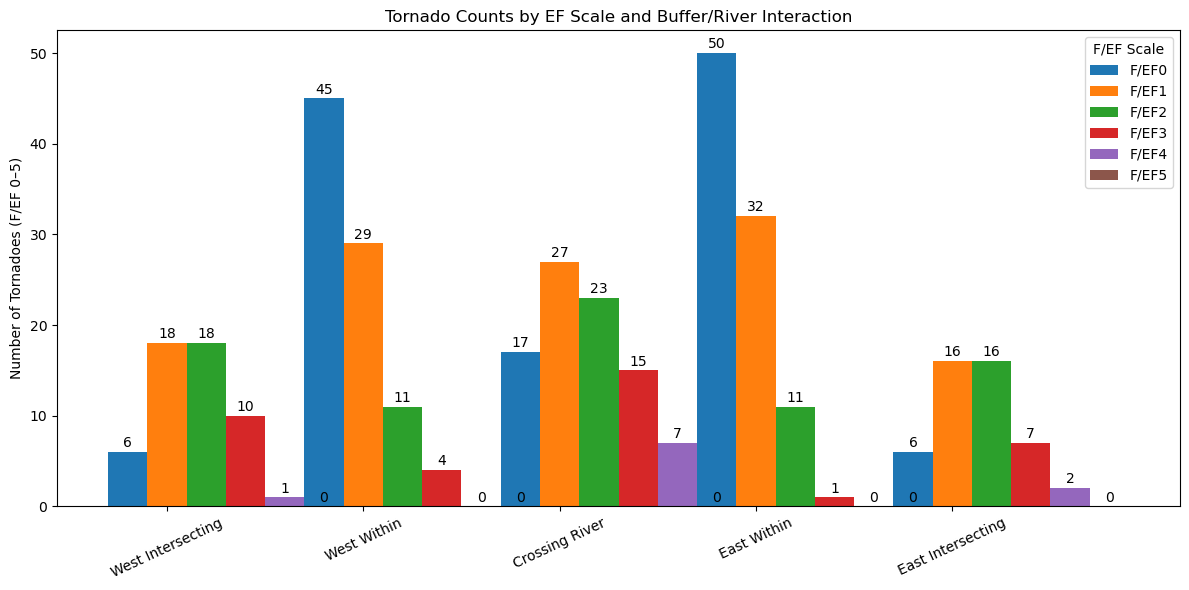

In [22]:
import matplotlib.pyplot as plt

# --- Step 1: Define helper to classify "completely within" vs "intersecting" ---
def completely_within(geom, buffer_geom):
    if geom.geom_type == "Point":
        return buffer_geom.contains(geom)
    elif geom.geom_type == "LineString":
        # Get boundary points as a list
        pts = list(geom.boundary.geoms)
        return buffer_geom.contains(pts[0]) and buffer_geom.contains(pts[1])
    return False

# --- Step 2: Separate the west and east tornadoes into intersecting vs completely within ---
west_intersecting = west_side[~west_side.apply(lambda r: completely_within(r.geometry, river_buffer), axis=1)]
west_within = west_side[west_side.apply(lambda r: completely_within(r.geometry, river_buffer), axis=1)]

east_intersecting = east_side[~east_side.apply(lambda r: completely_within(r.geometry, river_buffer), axis=1)]
east_within = east_side[east_side.apply(lambda r: completely_within(r.geometry, river_buffer), axis=1)]

# crossing already exists
crossing = crossing_tornadoes.copy()

# --- Step 3: Compute EF-scale counts for each bin ---
bins = {
    "West Intersecting": west_intersecting,
    "West Within": west_within,
    "Crossing River": crossing,
    "East Within": east_within,
    "East Intersecting": east_intersecting
}

ef_counts = {k: v['mag'].value_counts().reindex([0,1,2,3,4,5], fill_value=0) for k,v in bins.items()}

# Convert to DataFrame for plotting
ef_df = pd.DataFrame(ef_counts).T  # rows=bins, columns=EF scale
ef_df.index.name = 'Bin'
ef_df.columns = ['F/EF0', 'F/EF1', 'F/EF2', 'F/EF3', 'F/EF4', 'F/EF5']

# --- Step 4: Plot clustered bar chart ---
fig, ax = plt.subplots(figsize=(12,6))

bar_width = 0.2
x = np.arange(len(ef_df))  # 5 clusters

# Store bar containers for labeling
bars = []
for i, ef in enumerate(ef_df.columns):
    b = ax.bar(x + i*bar_width, ef_df[ef], width=bar_width, label=ef)
    bars.append(b)

# --- Add data labels on top of bars ---
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,  # center of the bar
            height + 0.2,                     # slightly above the bar
            f'{int(height)}',                 # convert to integer if counts
            ha='center', va='bottom', fontsize=10
        )

ax.set_xticks(x + bar_width)
ax.set_xticklabels(ef_df.index, rotation=25)
ax.set_ylabel("Number of Tornadoes (F/EF 0–5)")
ax.set_title("Tornado Counts by EF Scale and Buffer/River Interaction")
ax.legend(title="F/EF Scale")
plt.tight_layout()
plt.show()

Total tornadoes in plot: 372


/tmp/ipykernel_852/725604867.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




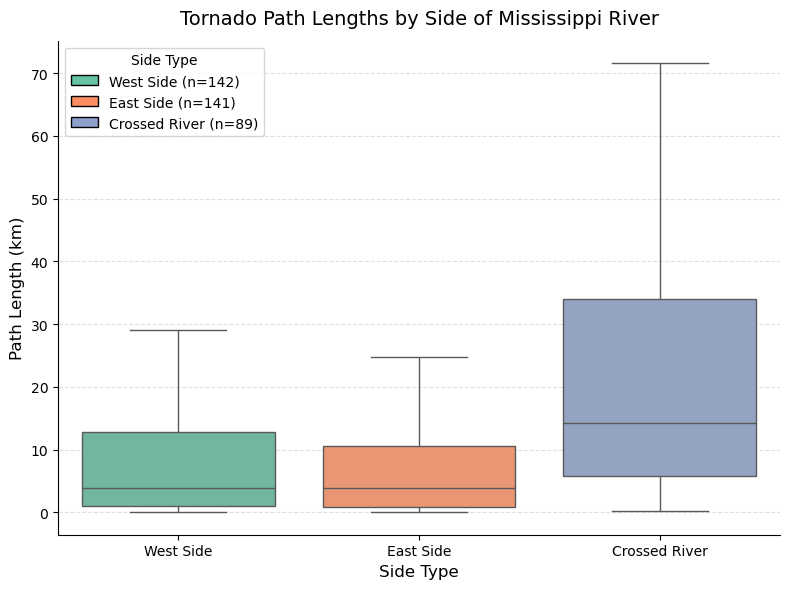

Total tornadoes in path length plot: 372

Five-number summary for tornado path lengths (km):
                    Min        Q1     Median         Q3         Max
side_type                                                          
Crossed River  0.160934  5.857998  14.162192  33.957074  237.216716
East Side      0.000000  0.836857   3.878509  10.621644  107.825780
West Side      0.064374  0.929394   3.942883  12.874720  147.254610


In [23]:
# --- Step 1: Combine intersecting + within for each side ---
west_side_plot = pd.concat([west_intersecting, west_within], ignore_index=True)
east_side_plot = pd.concat([east_intersecting, east_within], ignore_index=True)
cross_plot = crossing.copy()  # already exists

# Keep only path length and label each category
west_side_plot = west_side_plot[['len']].copy()
west_side_plot['side_type'] = "West Side"

east_side_plot = east_side_plot[['len']].copy()
east_side_plot['side_type'] = "East Side"

cross_plot = cross_plot[['len']].copy()
cross_plot['side_type'] = "Crossed River"

# --- Step 2: Convert path lengths to kilometers ---
for df in [west_side_plot, east_side_plot, cross_plot]:
    df['len'] = df['len'] * 1.60934  # miles → km

# --- Step 3: Combine for plotting ---
plot_df = pd.concat([west_side_plot, east_side_plot, cross_plot], ignore_index=True)
print("Total tornadoes in plot:", len(plot_df))  # Should be 372

# --- Step 4: Create boxplot ---
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=plot_df,
    x="side_type",
    y="len",
    palette=palette,
    showfliers=False
)

# --- Step 5: Build color-coded legend with counts ---
counts = plot_df["side_type"].value_counts()
legend_elements = [
    Patch(facecolor=palette[i], edgecolor='black',
          label=f"{cat} (n={counts[cat]})")
    for i, cat in enumerate(['West Side', 'East Side', 'Crossed River'])
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=10,
    title="Side Type",
    frameon=True
)

# --- Step 6: Final formatting ---
ax.set_title("Tornado Path Lengths by Side of Mississippi River", fontsize=14, pad=12)
ax.set_xlabel("Side Type", fontsize=12)
ax.set_ylabel("Path Length (km)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# Compute five-number summary for each category
summary_stats = plot_df.groupby("side_type")['len'].describe(percentiles=[0.25, 0.5, 0.75])[['min', '25%', '50%', '75%', 'max']]

# Rename columns for clarity
summary_stats.columns = ['Min', 'Q1', 'Median', 'Q3', 'Max']

# Display
print("Total tornadoes in path length plot:", len(plot_df))  # Should be 246
print("\nFive-number summary for tornado path lengths (km):")
print(summary_stats)

In [24]:
# --- Prepare data ---
groups = plot_df.groupby('side_type')['len'].apply(list)

# Extract group data
west_len = groups['West Side']
east_len = groups['East Side']
cross_len = groups['Crossed River']

# --- 1. Overall Kruskal-Wallis test ---
stat, p = kruskal(west_len, east_len, cross_len)
print(f"Overall Kruskal-Wallis test: H = {stat:.3f}, p = {p:.4f}")

# --- 2. Pairwise comparisons ---
pairs = list(itertools.combinations(groups.index, 2))
results = []
for a, b in pairs:
    stat, p = kruskal(groups[a], groups[b])
    results.append({'Group1': a, 'Group2': b, 'H': stat, 'p-value': p})

# Convert to DataFrame for readability
pairwise_df = pd.DataFrame(results)
print("\nPairwise Kruskal-Wallis results:")
print(pairwise_df)

#Evaluated at the 0.05 significance level.

Overall Kruskal-Wallis test: H = 42.261, p = 0.0000

Pairwise Kruskal-Wallis results:
          Group1     Group2          H       p-value
0  Crossed River  East Side  36.956769  1.207776e-09
1  Crossed River  West Side  30.462058  3.404605e-08
2      East Side  West Side   0.561019  4.538501e-01


### Kruskal-Wallis Test on Tornado Path Lengths for All Tornadoes (EF0–EF5) by Side of Mississippi River

**Overall Test:**
- Kruskal-Wallis H = 42.261, p = 0.0000  
- Interpretation: There is a statistically significant difference in tornado path lengths among the three groups (West Side, East Side, Crossed River).

### Pairwise Comparisons

| Group 1       | Group 2    | H         | p-value        | Significant? |
|---------------|------------|-----------|----------------|--------------|
| Crossed River | East Side  | 36.956769 | 1.21 × 10⁻⁹    | Yes          |
| Crossed River | West Side  | 30.462058 | 3.40 × 10⁻⁸    | Yes          |
| East Side     | West Side  | 0.561019  | 0.453850       | No           |

### Summary

- Tornadoes that **cross the river** have significantly different path lengths compared to tornadoes occurring on either side of the river.
- Tornadoes on the **West Side** and **East Side** exhibit statistically similar path length distributions.
- The strongest statistical signal occurs between the **Crossed River** and **East Side** populations, though both river-crossing comparisons remain highly significant.

Overall, these findings indicate that tornadoes directly interacting with the Mississippi River corridor tend to exhibit enhanced path length characteristics across the full tornado intensity spectrum (EF0–EF5), while tornadoes confined to either side of the river remain broadly similar to one another..in path length.

/tmp/ipykernel_852/2638795809.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




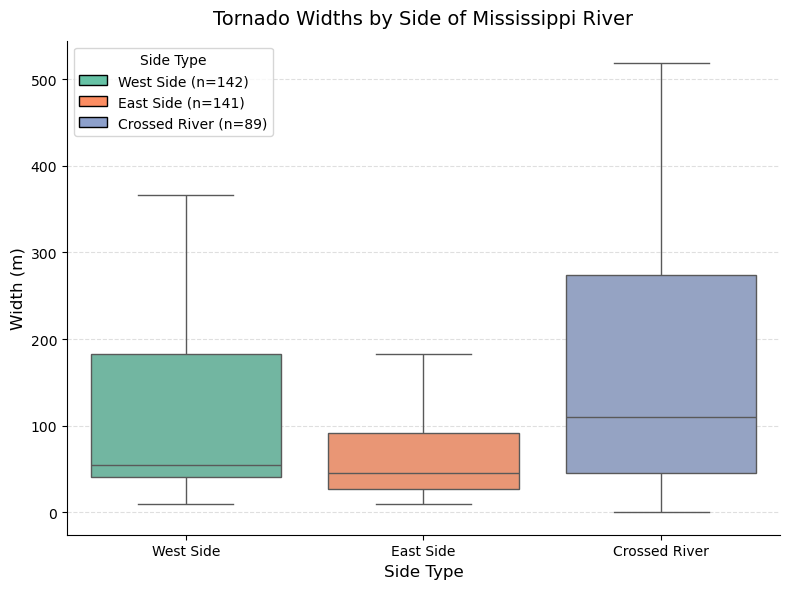

Total tornadoes in width plot: 372

Five-number summary for tornado widths (m):
                  min      25%      50%     75%       max
side_type                                               
Crossed River  0.000  45.7200  109.728  274.32  2011.680
East Side      9.144  27.4320   45.720   91.44   914.400
West Side      9.144  40.9194   54.864  182.88  1609.344


In [25]:
# --- Step 1: Prepare categories ---
categories = {
    'West Side': pd.concat([west_intersecting, west_within], ignore_index=True),
    'East Side': pd.concat([east_intersecting, east_within], ignore_index=True),
    'Crossed River': crossing.copy()
}

# --- Step 2: Map widths (yards -> meters) and side_type ---
dfs = []
for cat, df in categories.items():
    temp = df[['wid']].copy()
    temp['width_m'] = temp['wid'] * 0.9144  # convert yards -> meters
    temp['side_type'] = cat
    dfs.append(temp[['width_m','side_type']])

width_plot_df = pd.concat(dfs, ignore_index=True)

# --- Step 3: Boxplot ---
plt.figure(figsize=(8,6))
palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=width_plot_df,
    x='side_type',
    y='width_m',
    palette=palette,
    showfliers=False
)

# --- Step 4: Add legend with counts ---
counts = width_plot_df['side_type'].value_counts()
legend_elements = [
    Patch(facecolor=palette[i], edgecolor='black',
          label=f"{cat} (n={counts[cat]})")
    for i, cat in enumerate(['West Side', 'East Side', 'Crossed River'])
]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=10,
    title="Side Type",
    frameon=True
)

# --- Step 5: Formatting ---
ax.set_title("Tornado Widths by Side of Mississippi River", fontsize=14, pad=12)
ax.set_xlabel("Side Type", fontsize=12)
ax.set_ylabel("Width (m)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

print("Total tornadoes in width plot:", len(width_plot_df))

# --- Step 6: Compute five-number summary statistics ---
width_summary = width_plot_df.groupby('side_type')['width_m'].describe(percentiles=[0.25,0.5,0.75])[['min','25%','50%','75%','max']]
print("\nFive-number summary for tornado widths (m):\n", width_summary)

In [26]:
# Extract the groups
west_width = width_plot_df[width_plot_df['side_type'] == 'West Side']['width_m']
east_width = width_plot_df[width_plot_df['side_type'] == 'East Side']['width_m']
cross_width = width_plot_df[width_plot_df['side_type'] == 'Crossed River']['width_m']

# Overall Kruskal-Wallis test
H_overall, p_overall = kruskal(west_width, east_width, cross_width)
print(f"Overall Kruskal-Wallis test: H = {H_overall:.3f}, p = {p_overall:.4f}")

# Pairwise comparisons
groups = {'West Side': west_width, 'East Side': east_width, 'Crossed River': cross_width}
pairs = list(itertools.combinations(groups.keys(), 2))

pairwise_results = []
for g1, g2 in pairs:
    H, p = kruskal(groups[g1], groups[g2])
    pairwise_results.append({
        'Group1': g1,
        'Group2': g2,
        'H': H,
        'p-value': p
    })

pairwise_df = pd.DataFrame(pairwise_results)
print("\nPairwise Kruskal-Wallis results:")
print(pairwise_df)

#Evaluated at the 0.05 significance level.

Overall Kruskal-Wallis test: H = 25.171, p = 0.0000

Pairwise Kruskal-Wallis results:
      Group1         Group2          H   p-value
0  West Side      East Side   7.727088  0.005440
1  West Side  Crossed River   7.843006  0.005102
2  East Side  Crossed River  23.323568  0.000001


### Kruskal-Wallis Test on Tornado Widths for All Tornadoes (EF0–EF5) by Side of Mississippi River

**Overall Test:**
- Kruskal-Wallis H = 25.171, p = 0.0000  
- Interpretation: There is a statistically significant difference in tornado widths among the three groups (West Side, East Side, Crossed River).

### Pairwise Comparisons

| Group 1       | Group 2       | H         | p-value        | Significant? |
|---------------|---------------|-----------|----------------|--------------|
| West Side     | East Side     | 7.727088  | 0.005440       | Yes          |
| West Side     | Crossed River | 7.843006  | 0.005102       | Yes          |
| East Side     | Crossed River | 23.323568 | 0.000001       | Yes          |

### Summary

- Tornado widths differ significantly between **all three groups**:
  - **West Side vs. East Side**
  - **West Side vs. Crossed River**
  - **East Side vs. Crossed River**

- The strongest statistical contrast occurs between the **East Side** and **Crossed River** populations.

Overall, these findings indicate that tornado width exhibits substantial spatial variability across the Mississippi River corridor when considering all tornado intensities (EF0–EF5). Unlike earlier analyses, the updated results suggest that not only do **Crossed River tornadoes** differ from side-based populations, but the **West Side** and **East Side** populations also exhibit significantly different width characteristics from one another.

These results imply that both **river interaction** and **side-of-river spatial differences** may influence tornado width behavior across the study region..each other.ver.

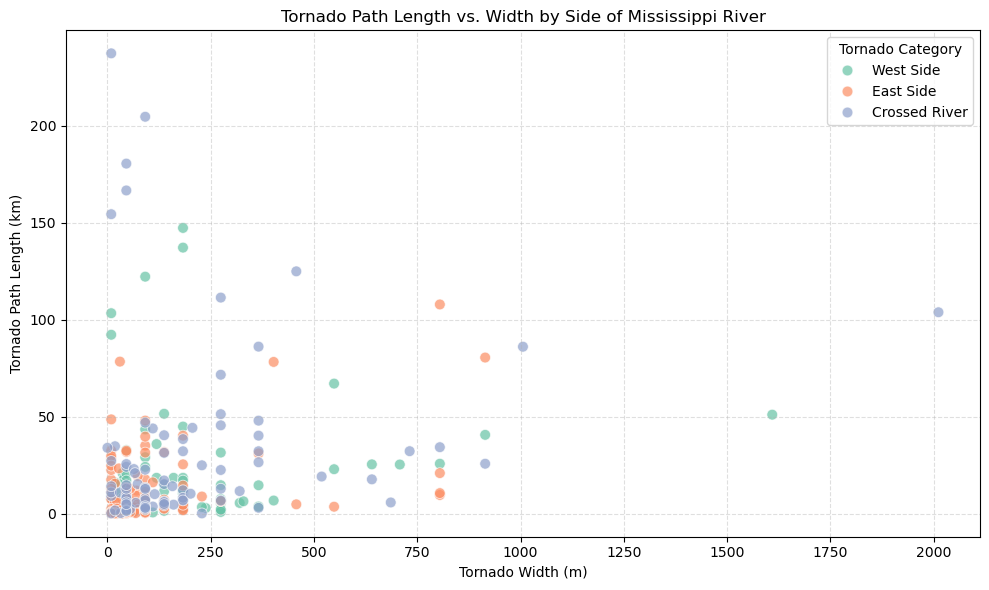

In [27]:
# --- Step 1: Combine pathlengths and widths into a single DataFrame ---
scatter_df = plot_df[['len','side_type']].copy()
scatter_df = scatter_df.rename(columns={'len':'len_km'})

# Add widths from width_plot_df using same index
scatter_df['width_m'] = width_plot_df['width_m']

# --- Step 2: Scatter plot ---
plt.figure(figsize=(10,6))
palette = sns.color_palette("Set2", 3)

sns.scatterplot(
    data=scatter_df,
    x='width_m',
    y='len_km',
    hue='side_type',
    palette=palette,
    s=60,
    alpha=0.7
)

plt.xlabel("Tornado Width (m)")
plt.ylabel("Tornado Path Length (km)")
plt.title("Tornado Path Length vs. Width by Side of Mississippi River")
plt.legend(title="Tornado Category")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [28]:
# --- Prepare DataFrame ---
scatter_df = plot_df[['len','side_type']].copy()
scatter_df = scatter_df.rename(columns={'len':'len_km'})
scatter_df['width_m'] = width_plot_df['width_m']

# --- Interactive scatterplot ---
fig = px.scatter(
    scatter_df,
    x='width_m',
    y='len_km',
    color='side_type',
    labels={
        'width_m': 'Tornado Width (m)',
        'len_km': 'Tornado Path Length (km)',
        'side_type': 'Tornado Category'
    },
    hover_data=['width_m', 'len_km', 'side_type'],
    title="Tornado Path Length vs. Width by Side of Mississippi River",
    width=900,
    height=600
)

# Optionally, add a rectangle to indicate the 0-150 km x 0-1000 m region
fig.add_shape(
    type="rect",
    x0=0, y0=0,
    x1=1000, y1=150,
    line=dict(color="red", width=2),
    fillcolor="rgba(0,0,0,0)"  # transparent fill
)

fig.show()

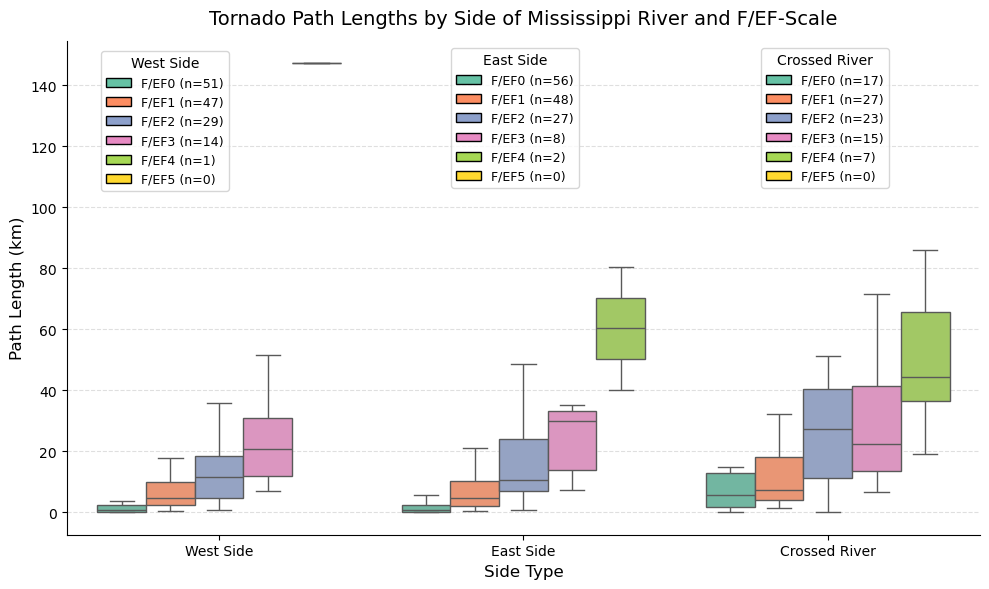

In [29]:
# --- Step 0: Prepare DataFrames for each tornado category ---
west_side_plot = pd.concat([west_intersecting, west_within], ignore_index=True)
east_side_plot = pd.concat([east_intersecting, east_within], ignore_index=True)
cross_plot = crossing.copy()

for df, name in zip([west_side_plot, east_side_plot, cross_plot],
                    ["West Side","East Side","Crossed River"]):
    df['side_type'] = name
    df['len'] = df['len'] * 1.60934  # miles -> km

west_side_plot = west_side_plot[['len','mag','side_type']]
east_side_plot = east_side_plot[['len','mag','side_type']]
cross_plot = cross_plot[['len','mag','side_type']]

plot_df = pd.concat([west_side_plot, east_side_plot, cross_plot], ignore_index=True)

# --- Step 1: Set palette for EF-scale ---
ef_palette = {0: "#66c2a5",1: "#fc8d62",2: "#8da0cb",3: "#e78ac3",4: "#a6d854",5: "#ffd92f"}  # EF0,1,2,3,4,5

# --- Step 2: Plot boxplot ---
plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=plot_df,
    x="side_type",
    y="len",
    hue="mag",
    palette=ef_palette,
    showfliers=False
)

ax.legend_.remove()

ax.set_title("Tornado Path Lengths by Side of Mississippi River and F/EF-Scale", fontsize=14, pad=12)
ax.set_xlabel("Side Type", fontsize=12)
ax.set_ylabel("Path Length (km)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

# --- Step 3: Build all three legends manually using fig.legend ---
fig = plt.gcf()
legend_elements = []

# For each cluster, create legend elements with counts
clusters = ['West Side','East Side','Crossed River']
positions = [(0.10, 0.915),(0.45, 0.92),(0.76, 0.92)]  # relative to figure

for cluster, pos in zip(clusters, positions):
    cluster_df = plot_df[plot_df['side_type'] == cluster]
    counts = cluster_df['mag'].value_counts().reindex([0,1,2,3,4,5], fill_value=0)
    cluster_legend = [Patch(facecolor=ef_palette[ef], edgecolor='black',
                            label=f"F/EF{ef} (n={counts[ef]})") for ef in [0,1,2,3,4,5]]
    fig.legend(handles=cluster_legend, title=cluster, loc='upper left', bbox_to_anchor=pos, fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

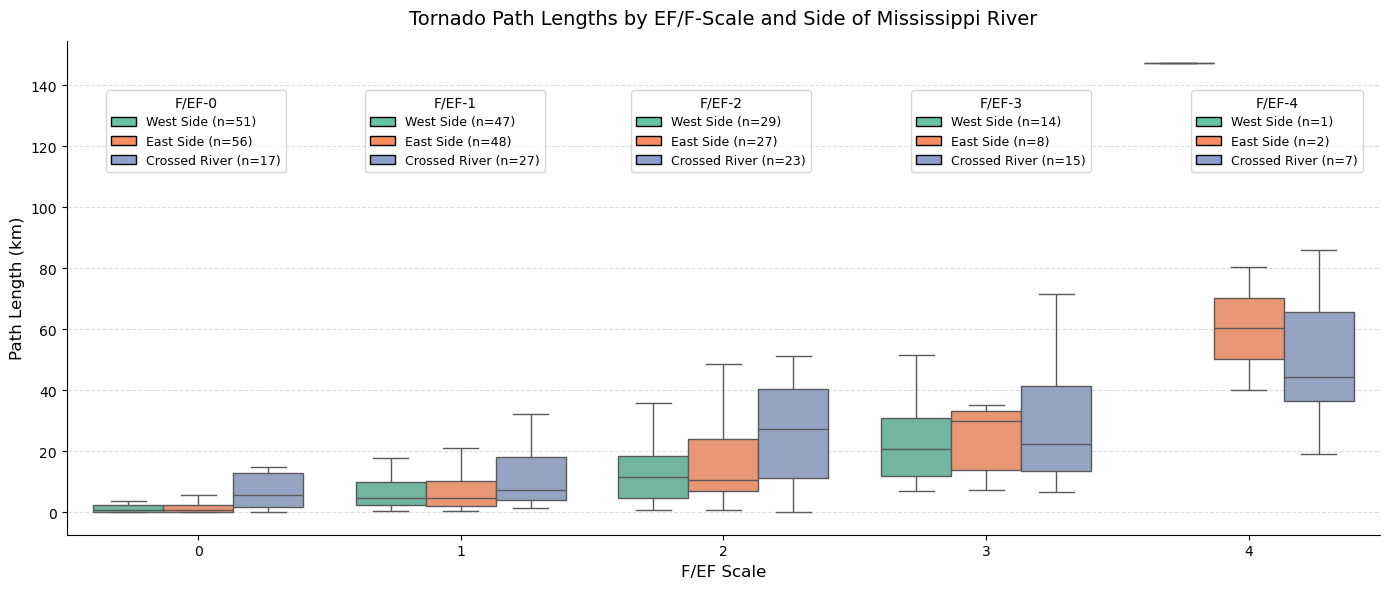

In [30]:
# --- Step 0: Prepare DataFrames ---
west_side_plot = pd.concat([west_intersecting, west_within], ignore_index=True)
east_side_plot = pd.concat([east_intersecting, east_within], ignore_index=True)
cross_plot = crossing.copy()

# --- Step 0: Prepare DataFrames ---
west_side_plot = pd.concat([west_intersecting, west_within], ignore_index=True)
east_side_plot = pd.concat([east_intersecting, east_within], ignore_index=True)
cross_plot = crossing.copy()

for df, name in zip([west_side_plot, east_side_plot, cross_plot],
                    ["West Side","East Side","Crossed River"]):
    df['side_type'] = name
    df['len'] = df['len'] * 1.60934  # miles -> km

west_side_plot = west_side_plot[['len','mag','side_type']]
east_side_plot = east_side_plot[['len','mag','side_type']]
cross_plot = cross_plot[['len','mag','side_type']]

plot_df = pd.concat([west_side_plot, east_side_plot, cross_plot], ignore_index=True)

# --- Step 1: Set palette for tornado categories ---
category_palette = {"West Side":"#66c2a5",
                    "East Side":"#fc8d62",
                    "Crossed River":"#8da0cb"}

# --- Step 2: Plot clustered boxplots ---
plt.figure(figsize=(14,6))
ax = sns.boxplot(
    data=plot_df,
    x="mag",                 # EF-scale on x-axis
    y="len",                 # Path length
    hue="side_type",         # Separate color per side
    palette=category_palette,
    showfliers=False
)

ax.legend_.remove()

ax.set_title("Tornado Path Lengths by EF/F-Scale and Side of Mississippi River", fontsize=14, pad=12)
ax.set_xlabel("F/EF Scale", fontsize=12)
ax.set_ylabel("Path Length (km)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

# --- Step 3: Add 3 legends, one per EF-scale ---
fig = plt.gcf()
ef_scales = [0,1,2,3,4,5]
legend_positions = [(0.075, 0.85),(0.26, 0.85),(0.45, 0.85),(0.65, 0.85),(0.85, 0.85)]  # top-left, top-center, top-right

for ef, pos in zip(ef_scales, legend_positions):
    # Extract counts for each side for this EF
    counts = {side: plot_df[(plot_df['side_type']==side) & (plot_df['mag']==ef)]['len'].count()
              for side in ['West Side','East Side','Crossed River']}
    
    legend_patches = [
        Patch(facecolor=category_palette[side], edgecolor='black',
              label=f"{side} (n={counts[side]})")
        for side in ['West Side','East Side','Crossed River']
    ]
    
    fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=pos,
               fontsize=9, frameon=True, title=f"F/EF-{ef}")

plt.tight_layout()
plt.show()

/tmp/ipykernel_852/1173265442.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_852/1173265442.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_852/1173265442.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_852/1173265442.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




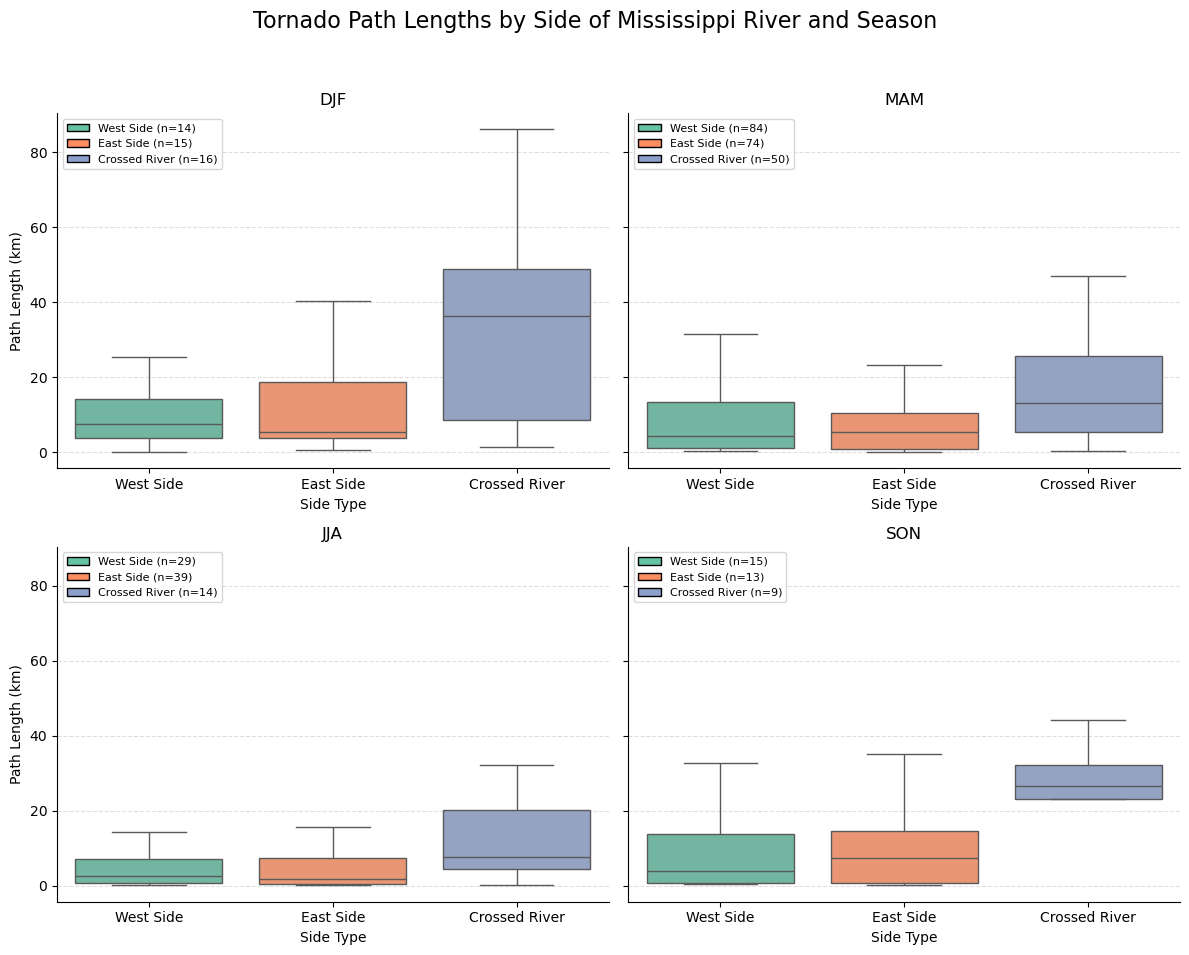

In [31]:
# ================================================================
# SEASONAL ANALYSIS BY SIDE TYPE (DJF, MAM, JJA, SON)
# ================================================================

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

tornado_gdf["season"] = tornado_gdf["date"].dt.month.apply(get_season)

buffer_tornadoes = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_tornadoes["season"] = buffer_tornadoes["date"].dt.month.apply(get_season)

import itertools

# --- Define palette ---
palette = {
    "West Side": "#66c2a5",
    "East Side": "#fc8d62",
    "Crossed River": "#8da0cb"
}

seasons = ["DJF","MAM","JJA","SON"]

fig, axes = plt.subplots(2,2, figsize=(12,10), sharey=True)
axes = axes.flatten()

season_results = {}

for i, season_name in enumerate(seasons):

    ax = axes[i]

    # --- Restrict to season ---
    season_df = buffer_tornadoes[buffer_tornadoes["season"] == season_name].copy()

    season_df["len_km"] = season_df["len"] * 1.60934

    # --- Assign side labels ---
    season_df.loc[season_df.index.isin(west_side.index), "side_type"] = "West Side"
    season_df.loc[season_df.index.isin(east_side.index), "side_type"] = "East Side"
    season_df.loc[season_df.index.isin(crossing_tornadoes.index), "side_type"] = "Crossed River"

    season_results[season_name] = season_df

    # --- Boxplot ---
    sns.boxplot(
        data=season_df,
        x="side_type",
        y="len_km",
        palette=palette,
        showfliers=False,
        ax=ax
    )

    counts = season_df["side_type"].value_counts()

    legend_elements = [
        Patch(facecolor=palette[k], edgecolor='black',
              label=f"{k} (n={counts[k]})")
        for k in ["West Side","East Side","Crossed River"]
    ]

    ax.legend(handles=legend_elements, fontsize=8, loc="upper left")
    ax.set_title(season_name)
    ax.set_xlabel("Side Type")

    if i % 2 == 0:
        ax.set_ylabel("Path Length (km)")
    else:
        ax.set_ylabel("")

    ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()

plt.suptitle(
    "Tornado Path Lengths by Side of Mississippi River and Season",
    fontsize=16
)

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

In [32]:
# ================================================================
# STATISTICAL TESTS FOR EACH SEASON
# ================================================================

for season_name, season_df in season_results.items():

    print("\n=====================================================")
    print(f"{season_name} TORNADO PATH LENGTH ANALYSIS")
    print("=====================================================")

    # --- Five number summary ---
    summary = season_df.groupby("side_type")["len_km"].describe(
        percentiles=[0.25,0.5,0.75]
    )[["min","25%","50%","75%","max"]]

    print("\nFive-number summary (km):\n")
    print(summary)

    # --- Kruskal-Wallis ---
    groups = season_df.groupby("side_type")["len_km"].apply(list)

    H, p = kruskal(
        groups["West Side"],
        groups["East Side"],
        groups["Crossed River"]
    )

    print("\nKruskal-Wallis Test")
    print("----------------------")
    print(f"H = {H:.3f}, p = {p:.6f}")

    if p < 0.05:
        print("Interpretation: Statistically significant difference among groups.")
    else:
        print("Interpretation: No statistically significant difference among groups.")

    # --- Pairwise comparisons ---
    pairs = list(itertools.combinations(groups.index,2))
    results = []

    for a,b in pairs:

        stat, p_val = kruskal(groups[a], groups[b])

        results.append({
            "Group1":a,
            "Group2":b,
            "H":stat,
            "p-value":p_val,
            "Significant?":"Yes" if p_val < 0.05 else "No"
        })

    pairwise_df = pd.DataFrame(results)
    
    print("\nPairwise Kruskal-Wallis results:")
    print(pairwise_df)


DJF TORNADO PATH LENGTH ANALYSIS

Five-number summary (km):

                    min       25%        50%        75%         max
side_type                                                          
Crossed River  1.384032  8.593876  36.210150  48.791165  154.335706
East Side      0.627643  3.830229   5.246448  18.579830   40.233500
West Side      0.064374  3.842299   7.467338  14.226566   43.452180

Kruskal-Wallis Test
----------------------
H = 8.941, p = 0.011439
Interpretation: Statistically significant difference among groups.

Pairwise Kruskal-Wallis results:
          Group1     Group2         H   p-value Significant?
0  Crossed River  East Side  6.911159  0.008566          Yes
1  Crossed River  West Side  6.119305  0.013371          Yes
2      East Side  West Side  0.057633  0.810277           No

MAM TORNADO PATH LENGTH ANALYSIS

Five-number summary (km):

                    min       25%        50%        75%         max
side_type                                              

## Kruskal–Wallis Tests on Seasonal Tornado Path Lengths by Side of the Mississippi River (EF0–EF5)

### DJF Season

#### Overall Test

**Kruskal–Wallis H = 8.941, p = 0.011439**

Interpretation: There is a statistically significant difference in tornado path lengths among the three groups (West Side, East Side, Crossed River) during the DJF season.

#### Pairwise Kruskal–Wallis Results

| Group 1 | Group 2 | H | p-value | Significant? |
|--------|--------|------|--------|--------------|
| Crossed River | East Side | 6.911 | 0.008566 | Yes |
| Crossed River | West Side | 6.119 | 0.013371 | Yes |
| East Side | West Side | 0.058 | 0.810277 | No |

#### Five-Number Summary (Path Length, km)

| Group | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| Crossed River | 1.384 | 8.594 | 36.210 | 48.791 | 154.336 |
| East Side | 0.628 | 3.830 | 5.246 | 18.580 | 40.234 |
| West Side | 0.064 | 3.842 | 7.467 | 14.227 | 43.452 |

#### Summary

During DJF, tornadoes that cross the Mississippi River exhibit significantly longer path lengths than tornadoes that occur solely on either side of the river buffer. Pairwise comparisons indicate that Crossed River tornadoes differ significantly from both East Side and West Side tornadoes, while the East Side and West Side groups do not differ significantly from one another.

---

### MAM Season

#### Overall Test

**Kruskal–Wallis H = 20.200, p = 0.000041**

Interpretation: There is a statistically significant difference in tornado path lengths among the three groups during the MAM season.

#### Pairwise Kruskal–Wallis Results

| Group 1 | Group 2 | H | p-value | Significant? |
|--------|--------|------|--------|--------------|
| Crossed River | East Side | 18.994 | 0.000013 | Yes |
| Crossed River | West Side | 13.145 | 0.000288 | Yes |
| East Side | West Side | 0.474 | 0.491233 | No |

#### Five-Number Summary (Path Length, km)

| Group | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| Crossed River | 0.161 | 5.347 | 13.116 | 25.709 | 204.547 |
| East Side | 0.000 | 0.841 | 5.230 | 10.400 | 107.826 |
| West Side | 0.161 | 1.183 | 4.345 | 13.317 | 147.255 |

#### Summary

During MAM, tornadoes that cross the Mississippi River have significantly longer path lengths than tornadoes occurring solely on either side of the river buffer. Pairwise comparisons indicate significant differences between Crossed River tornadoes and both East Side and West Side tornadoes. No statistically significant difference exists between tornadoes occurring on the East Side and West Side of the river.

---

### JJA Season

#### Overall Test

**Kruskal–Wallis H = 6.771, p = 0.033857**

Interpretation: There is a statistically significant difference in tornado path lengths among the three groups during the JJA season.

#### Pairwise Kruskal–Wallis Results

| Group 1 | Group 2 | H | p-value | Significant? |
|--------|--------|------|--------|--------------|
| Crossed River | East Side | 6.219 | 0.012635 | Yes |
| Crossed River | West Side | 4.686 | 0.030409 | Yes |
| East Side | West Side | 0.305 | 0.580843 | No |

#### Five-Number Summary (Path Length, km)

| Group | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| Crossed River | 0.161 | 4.498 | 7.580 | 20.097 | 237.217 |
| East Side | 0.080 | 0.467 | 1.786 | 7.322 | 78.214 |
| West Side | 0.129 | 0.805 | 2.575 | 7.097 | 29.129 |

#### Summary

During JJA, tornadoes that cross the Mississippi River exhibit significantly longer path lengths than tornadoes confined to either side of the river buffer. Similar to the DJF and MAM seasons, pairwise comparisons show significant differences between Crossed River tornadoes and both East Side and West Side tornadoes, while the East Side and West Side groups do not differ significantly from one another.

---

### SON Season

#### Overall Test

**Kruskal–Wallis H = 4.822, p = 0.089747**

Interpretation: No statistically significant differences in tornado path length were detected among the three groups during the SON season.

#### Pairwise Kruskal–Wallis Results

| Group 1 | Group 2 | H | p-value | Significant? |
|--------|--------|------|--------|--------------|
| Crossed River | East Side | 3.372 | 0.066299 | No |
| Crossed River | West Side | 4.234 | 0.039626 | Yes |
| East Side | West Side | 0.001 | 0.981622 | No |

#### Five-Number Summary (Path Length, km)

| Group | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| Crossed River | 0.322 | 23.014 | 26.506 | 32.219 | 103.802 |
| East Side | 0.064 | 0.563 | 7.242 | 14.484 | 78.375 |
| West Side | 0.467 | 0.813 | 4.023 | 13.792 | 92.215 |

#### Summary

During SON, no statistically significant overall differences in tornado path lengths were detected among the three groups. While the pairwise comparison between Crossed River and West Side tornadoes suggests a potential difference, the overall Kruskal–Wallis test does not indicate a statistically significant seasonal effect.

---

### Overall Interpretation

Across most seasons (DJF, MAM, and JJA), tornadoes that cross the Mississippi River tend to have significantly longer path lengths than tornadoes that occur exclusively on either the west or east sides of the river buffer. In contrast, tornadoes confined to the west and east sides of the river generally do not differ significantly from each other in path length.

The strongest seasonal signal appears during MAM, when Crossed River tornadoes show substantially longer median and upper-quartile path lengths than both side-based populations. Significant differences also persist during DJF and JJA, reinforcing the consistency of the cross-river signal across multiple seasons.

During SON, however, the overall test is not statistically significant, suggesting weaker or less consistent seasonal differences during the autumn period, potentially due to reduced sample size and lower regional tornado frequency.

/tmp/ipykernel_852/524298279.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




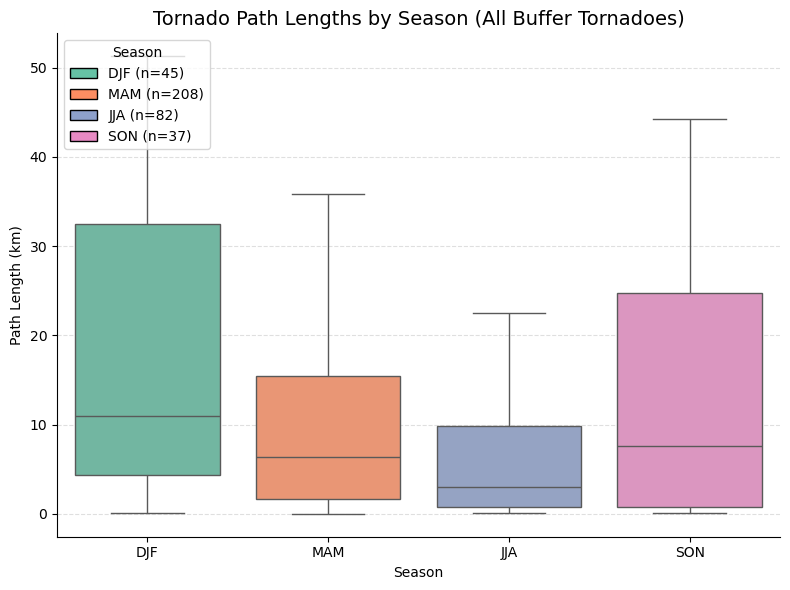


Five-number summary for tornado path lengths by season (km):

             min       25%        50%        75%         max
season                                                      
DJF     0.064374  4.361311  10.927419  32.508668  154.335706
JJA     0.080467  0.804670   2.993372   9.897441  237.216716
MAM     0.000000  1.609340   6.381033  15.489897  204.547114
SON     0.064374  0.820763   7.563898  24.783836  103.802430


In [33]:
# ================================================================
# ALL TORNADOES INTERSECTING/WITHIN BUFFER — PATH LENGTH BY SEASON
# ================================================================

season_df = buffer_tornadoes.copy()
season_df["len_km"] = season_df["len"] * 1.60934

# --- Step 1: Boxplot ---
plt.figure(figsize=(8,6))

season_order = ["DJF","MAM","JJA","SON"]

ax = sns.boxplot(
    data=season_df,
    x="season",
    y="len_km",
    order=season_order,
    palette="Set2",
    showfliers=False
)

counts = season_df["season"].value_counts().reindex(season_order)

legend_elements = [
    Patch(facecolor=sns.color_palette("Set2")[i], edgecolor='black',
          label=f"{season_order[i]} (n={counts[season_order[i]]})")
    for i in range(4)
]

ax.legend(handles=legend_elements, title="Season", loc="upper left")
ax.set_title("Tornado Path Lengths by Season (All Buffer Tornadoes)", fontsize=14)
ax.set_xlabel("Season")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# --- Step 2: Five-number summary ---
season_summary = season_df.groupby("season")["len_km"].describe(percentiles=[0.25,0.5,0.75])[["min","25%","50%","75%","max"]]
print("\nFive-number summary for tornado path lengths by season (km):\n")
print(season_summary)

In [34]:
# --- Step 3: Kruskal-Wallis test ---
groups = season_df.groupby("season")["len_km"].apply(list)

H, p = kruskal(groups["DJF"],
               groups["MAM"],
               groups["JJA"],
               groups["SON"])

print("\nKruskal-Wallis Test on Tornado Path Lengths by Season")
print("--------------------------------------------------------")
print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: There is a statistically significant difference in path length among seasons.")
else:
    print("Interpretation: No statistically significant difference in path length among seasons.")


Kruskal-Wallis Test on Tornado Path Lengths by Season
--------------------------------------------------------
Kruskal-Wallis H = 19.021, p = 0.0003
Interpretation: There is a statistically significant difference in path length among seasons.


In [35]:
# --------------------------------------------------------
# Pairwise Kruskal-Wallis Comparisons by Season
# --------------------------------------------------------

import itertools

groups = season_df.groupby("season")["len_km"].apply(list)

pairs = list(itertools.combinations(["DJF","MAM","JJA","SON"], 2))

results = []
for a, b in pairs:
    stat, p = kruskal(groups[a], groups[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)
print(pairwise_df)

  Group1 Group2          H   p-value Significant?
0    DJF    MAM   7.275809  0.006989          Yes
1    DJF    JJA  18.253941  0.000019          Yes
2    DJF    SON   1.582633  0.208382           No
3    MAM    JJA   7.213831  0.007234          Yes
4    MAM    SON   0.497054  0.480797           No
5    JJA    SON   4.711675  0.029958          Yes


In [36]:
pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 6
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print(pairwise_df)

  Group1 Group2          H   p-value Significant?  Adj p-value (Bonferroni)  \
0    DJF    MAM   7.275809  0.006989          Yes                  0.041934   
1    DJF    JJA  18.253941  0.000019          Yes                  0.000116   
2    DJF    SON   1.582633  0.208382           No                  1.250291   
3    MAM    JJA   7.213831  0.007234          Yes                  0.043406   
4    MAM    SON   0.497054  0.480797           No                  2.884784   
5    JJA    SON   4.711675  0.029958          Yes                  0.179751   

  Adj Significant?  
0              Yes  
1              Yes  
2               No  
3              Yes  
4               No  
5               No  


## Kruskal–Wallis Test on Tornado Path Lengths by Season (All Tornadoes Within/Intersecting the 10 km Buffer)

### Overall Test

**Kruskal–Wallis H = 19.021, p = 0.0003**

Interpretation: There is a statistically significant difference in tornado path lengths among seasons when considering all tornadoes that occur within or intersect the 10 km Mississippi River buffer.

---

### Pairwise Kruskal–Wallis Results (Bonferroni Corrected)

| Group 1 | Group 2 | H | p-value | Bonferroni Adjusted p-value | Significant? |
|--------|--------|------|--------|------------------------------|--------------|
| DJF | MAM | 7.276 | 0.006989 | 0.041934 | Yes |
| DJF | JJA | 18.254 | 0.000019 | 0.000116 | Yes |
| DJF | SON | 1.583 | 0.208382 | 1.250291 | No |
| MAM | JJA | 7.214 | 0.007234 | 0.043406 | Yes |
| MAM | SON | 0.497 | 0.480797 | 2.884784 | No |
| JJA | SON | 4.712 | 0.029958 | 0.179751 | No |

---

### Five-Number Summary (Path Length, km)

| Season | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| DJF | 0.064 | 4.361 | 10.927 | 32.509 | 154.336 |
| JJA | 0.080 | 0.805 | 2.993 | 9.897 | 237.217 |
| MAM | 0.000 | 1.609 | 6.381 | 15.490 | 204.547 |
| SON | 0.064 | 0.821 | 7.564 | 24.784 | 103.802 |

---

### Summary

Seasonal differences in tornado path length are statistically significant overall (H = 19.021, p = 0.0003). Pairwise comparisons with Bonferroni correction indicate that:

- Tornado path lengths differ significantly between **DJF and MAM** and between **DJF and JJA**.
- Tornado path lengths also differ significantly between **MAM and JJA**.
- No statistically significant differences were found between **DJF and SON**, **MAM and SON**, or **JJA and SON** after adjustment for multiple comparisons.

Median path lengths are largest during **DJF (10.9 km)** and **SON (7.6 km)**, while **JJA exhibits the shortest median path lengths (3.0 km)**. These results suggest that tornadoes occurring during winter and fall tend to have longer tracks on average compared to those during summer, with spring representing an intermediate regime within the Mississippi River buffer region. However, it is important to note the difference in sample sizes across seasons, with DJF and SON containing the fewest tornadoes within the buffer zone, which may explain the inflated path length values. 

/tmp/ipykernel_852/133932131.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




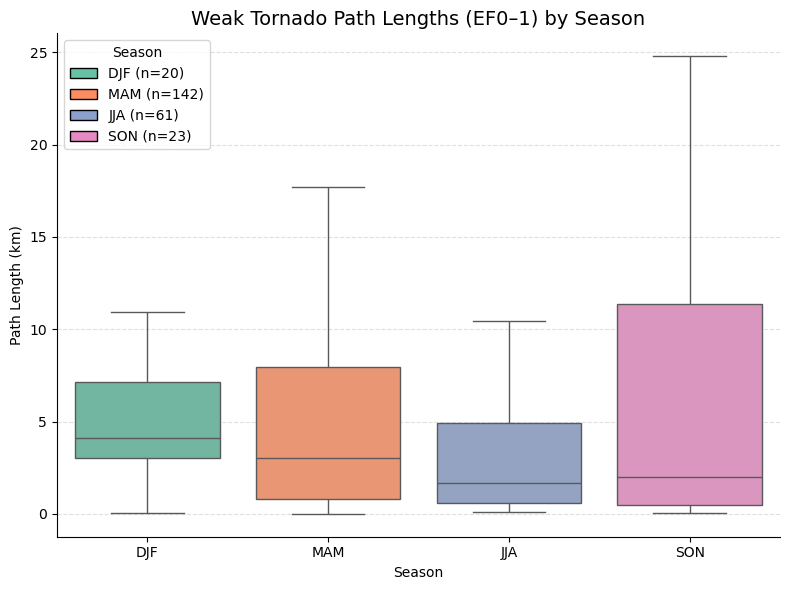


Five-number summary for WEAK tornado path lengths (km):

             min       25%       50%        75%         max
season                                                     
DJF     0.064374  3.029583  4.119910   7.145470  154.335706
JJA     0.080467  0.611549  1.673714   4.908487  237.216716
MAM     0.000000  0.804670  3.017513   7.970256  166.566690
SON     0.064374  0.482802  1.995582  11.369987   32.733976


In [37]:
# ================================================================
# WEAK TORNADOES (EF0–1) — PATH LENGTH BY SEASON
# ================================================================

# --- Step 1: Boxplot ---
weak_df = season_df[season_df["mag"].isin([0,1])].copy()

plt.figure(figsize=(8,6))

season_order = ["DJF","MAM","JJA","SON"]

ax = sns.boxplot(
    data=weak_df,
    x="season",
    y="len_km",
    order=season_order,
    palette="Set2",
    showfliers=False
)

counts = weak_df["season"].value_counts().reindex(season_order)

legend_elements = [
    Patch(facecolor=sns.color_palette("Set2")[i], edgecolor='black',
          label=f"{season_order[i]} (n={counts[season_order[i]]})")
    for i in range(4)
]

ax.legend(handles=legend_elements, title="Season", loc="upper left")
ax.set_title("Weak Tornado Path Lengths (EF0–1) by Season", fontsize=14)
ax.set_xlabel("Season")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# --- Step 2: Five-number summary ---
weak_summary = weak_df.groupby("season")["len_km"].describe(
    percentiles=[0.25,0.5,0.75]
)[["min","25%","50%","75%","max"]]

print("\nFive-number summary for WEAK tornado path lengths (km):\n")
print(weak_summary)

In [38]:
# --- Step 3: Kruskal-Wallis test ---
groups = weak_df.groupby("season")["len_km"].apply(list)

H, p = kruskal(groups["DJF"],
               groups["MAM"],
               groups["JJA"],
               groups["SON"])

print("\nKruskal-Wallis Test on WEAK Tornado Path Lengths by Season")
print("--------------------------------------------------------------")
print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: Significant seasonal differences in weak tornado path length.")
else:
    print("Interpretation: No significant seasonal differences in weak tornado path length.")


Kruskal-Wallis Test on WEAK Tornado Path Lengths by Season
--------------------------------------------------------------
Kruskal-Wallis H = 5.130, p = 0.1625
Interpretation: No significant seasonal differences in weak tornado path length.


In [39]:
# --------------------------------------------------------
# Pairwise Kruskal-Wallis Comparisons by Season
# --------------------------------------------------------

import itertools

groups = weak_df.groupby("season")["len_km"].apply(list)

pairs = list(itertools.combinations(["DJF","MAM","JJA","SON"], 2))

results = []
for a, b in pairs:
    stat, p = kruskal(groups[a], groups[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)
print(pairwise_df)

  Group1 Group2         H   p-value Significant?
0    DJF    MAM  1.420269  0.233359           No
1    DJF    JJA  4.849577  0.027653          Yes
2    DJF    SON  0.925259  0.336098           No
3    MAM    JJA  2.797301  0.094423           No
4    MAM    SON  0.013844  0.906338           No
5    JJA    SON  0.374770  0.540416           No


In [40]:
pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 6
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print(pairwise_df)

  Group1 Group2         H   p-value Significant?  Adj p-value (Bonferroni)  \
0    DJF    MAM  1.420269  0.233359           No                  1.400155   
1    DJF    JJA  4.849577  0.027653          Yes                  0.165918   
2    DJF    SON  0.925259  0.336098           No                  2.016587   
3    MAM    JJA  2.797301  0.094423           No                  0.566539   
4    MAM    SON  0.013844  0.906338           No                  5.438026   
5    JJA    SON  0.374770  0.540416           No                  3.242494   

  Adj Significant?  
0               No  
1               No  
2               No  
3               No  
4               No  
5               No  


## Kruskal–Wallis Test on Weak Tornado Path Lengths (EF0–1) by Season

### Overall Test

**Kruskal–Wallis H = 5.130, p = 0.1625**

Interpretation: No statistically significant differences were found in weak tornado path lengths among seasons within the 10 km Mississippi River buffer.

---

### Pairwise Kruskal–Wallis Results (Bonferroni Corrected)

| Group 1 | Group 2 | H | p-value | Bonferroni Adjusted p-value | Significant? |
|--------|--------|------|--------|------------------------------|--------------|
| DJF | MAM | 1.420 | 0.233359 | 1.400155 | No |
| DJF | JJA | 4.850 | 0.027653 | 0.165918 | No |
| DJF | SON | 0.925 | 0.336098 | 2.016587 | No |
| MAM | JJA | 2.797 | 0.094423 | 0.566539 | No |
| MAM | SON | 0.014 | 0.906338 | 5.438026 | No |
| JJA | SON | 0.375 | 0.540416 | 3.242494 | No |

---

### Five-Number Summary (Weak Tornado Path Length, km)

| Season | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| DJF | 0.064 | 3.030 | 4.120 | 7.145 | 154.336 |
| JJA | 0.080 | 0.612 | 1.674 | 4.908 | 237.217 |
| MAM | 0.000 | 0.805 | 3.018 | 7.970 | 166.567 |
| SON | 0.064 | 0.483 | 1.996 | 11.370 | 32.734 |

---

### Summary

Weak tornado path lengths do not exhibit statistically significant seasonal differences within the Mississippi River buffer region (p = 0.1625). Pairwise comparisons also reveal no statistically significant differences after Bonferroni correction. Although the DJF–JJA comparison initially appears significant using unadjusted p-values (p = 0.0277), this difference does not remain significant after accounting for multiple comparisons.

Median path lengths remain relatively similar across seasons for weak tornadoes, ranging from approximately **1.7 km (JJA)** to **4.1 km (DJF)**. The relatively small sample sizes in DJF (n = 20) and SON (n = 23) may reduce statistical power for detecting subtle seasonal differences. Overall, these findings suggest that seasonal variability in tornado path length within the Mississippi River buffer is not strongly influenced by weak tornado events and is likely driven by stronger tornado occurrences.

/tmp/ipykernel_852/2967376558.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




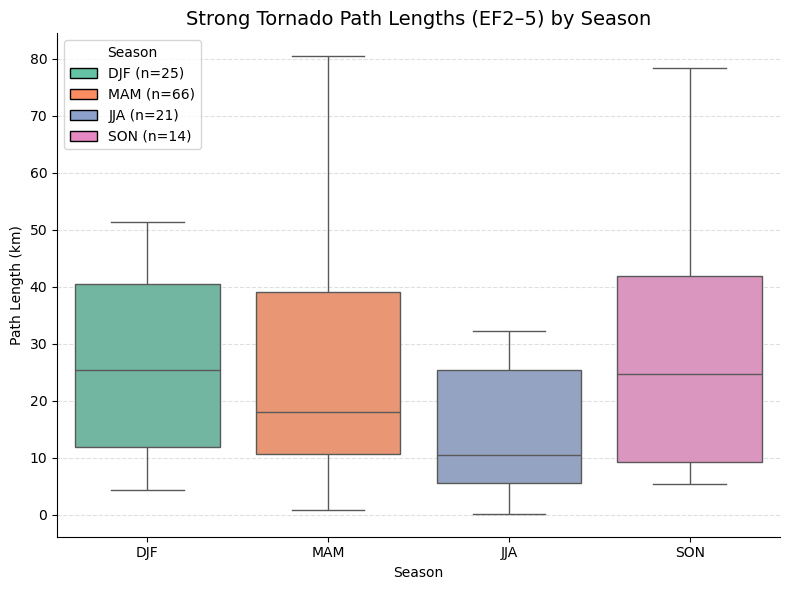


Five-number summary for STRONG tornado path lengths (km):

             min        25%        50%        75%         max
season                                                       
DJF     4.345218  11.909116  25.427572  40.426621  124.884784
JJA     0.160934   5.536130  10.460710  25.347105   78.213924
MAM     0.836857  10.681994  18.105075  39.147196  204.547114
SON     5.310822   9.293938  24.759696  41.963541  103.802430


In [41]:
# ================================================================
# STRONG TORNADOES (EF2–5) — PATH LENGTH BY SEASON
# ================================================================

# --- Step 1: Boxplot ---
strong_df = season_df[season_df["mag"].isin([2,3,4,5])].copy()

plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=strong_df,
    x="season",
    y="len_km",
    order=season_order,
    palette="Set2",
    showfliers=False
)

counts = strong_df["season"].value_counts().reindex(season_order)

legend_elements = [
    Patch(facecolor=sns.color_palette("Set2")[i], edgecolor='black',
          label=f"{season_order[i]} (n={counts[season_order[i]]})")
    for i in range(4)
]

ax.legend(handles=legend_elements, title="Season", loc="upper left")
ax.set_title("Strong Tornado Path Lengths (EF2–5) by Season", fontsize=14)
ax.set_xlabel("Season")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

# --- Step 2: Five-number summary ---
strong_summary = strong_df.groupby("season")["len_km"].describe(
    percentiles=[0.25,0.5,0.75]
)[["min","25%","50%","75%","max"]]

print("\nFive-number summary for STRONG tornado path lengths (km):\n")
print(strong_summary)

In [42]:
# --- Step 3: Kruskal-Wallis test ---
groups = strong_df.groupby("season")["len_km"].apply(list)

H, p = kruskal(groups["DJF"],
               groups["MAM"],
               groups["JJA"],
               groups["SON"])

print("\nKruskal-Wallis Test on STRONG Tornado Path Lengths by Season")
print("---------------------------------------------------------------")
print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.4f}")

if p < 0.05:
    print("Interpretation: Significant seasonal differences in strong tornado path length.")
else:
    print("Interpretation: No significant seasonal differences in strong tornado path length.")


Kruskal-Wallis Test on STRONG Tornado Path Lengths by Season
---------------------------------------------------------------
Kruskal-Wallis H = 7.383, p = 0.0606
Interpretation: No significant seasonal differences in strong tornado path length.


In [43]:
# --------------------------------------------------------
# Pairwise Kruskal-Wallis Comparisons for STRONG Tornadoes
# --------------------------------------------------------

import itertools

groups = strong_df.groupby("season")["len_km"].apply(list)

pairs = list(itertools.combinations(["DJF","MAM","JJA","SON"], 2))

results = []

for a, b in pairs:
    stat, p = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)
print(pairwise_df)

  Group1 Group2         H   p-value Significant?
0    DJF    MAM  0.265961  0.606054           No
1    DJF    JJA  5.779063  0.016218          Yes
2    DJF    SON  0.013716  0.906770           No
3    MAM    JJA  5.364838  0.020547          Yes
4    MAM    SON  0.213629  0.643938           No
5    JJA    SON  4.219412  0.039964          Yes


In [44]:
# --------------------------------------------------------
# Bonferroni Correction
# --------------------------------------------------------

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 6

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print(pairwise_df)

  Group1 Group2         H   p-value Significant?  Adj p-value (Bonferroni)  \
0    DJF    MAM  0.265961  0.606054           No                  3.636326   
1    DJF    JJA  5.779063  0.016218          Yes                  0.097309   
2    DJF    SON  0.013716  0.906770           No                  5.440619   
3    MAM    JJA  5.364838  0.020547          Yes                  0.123280   
4    MAM    SON  0.213629  0.643938           No                  3.863625   
5    JJA    SON  4.219412  0.039964          Yes                  0.239784   

  Adj Significant?  
0               No  
1               No  
2               No  
3               No  
4               No  
5               No  


## Kruskal–Wallis Test on Strong Tornado Path Lengths (EF2–5) by Season

### Overall Test

**Kruskal–Wallis H = 7.383, p = 0.0606**

Interpretation: No statistically significant differences were found in strong tornado path lengths among seasons within the 10 km Mississippi River buffer (p > 0.05).

---

### Pairwise Kruskal–Wallis Results (Bonferroni Corrected)

| Group 1 | Group 2 | H | p-value | Bonferroni Adjusted p-value | Significant? |
|--------|--------|------|--------|------------------------------|--------------|
| DJF | MAM | 0.266 | 0.606054 | 3.636326 | No |
| DJF | JJA | 5.779 | 0.016218 | 0.097309 | No |
| DJF | SON | 0.014 | 0.906770 | 5.440619 | No |
| MAM | JJA | 5.365 | 0.020547 | 0.123280 | No |
| MAM | SON | 0.214 | 0.643938 | 3.863625 | No |
| JJA | SON | 4.219 | 0.039964 | 0.239784 | No |

---

### Five-Number Summary (Strong Tornado Path Length, km)

| Season | Min | 25% | Median | 75% | Max |
|------|------|------|------|------|------|
| DJF | 4.345 | 11.909 | 25.428 | 40.427 | 124.885 |
| JJA | 0.161 | 5.536 | 10.461 | 25.347 | 78.214 |
| MAM | 0.837 | 10.682 | 18.105 | 39.147 | 204.547 |
| SON | 5.311 | 9.294 | 24.760 | 41.964 | 103.802 |

---

### Summary

Strong tornado path lengths do not exhibit statistically significant seasonal differences within the Mississippi River buffer region (p = 0.0606). Although several pairwise comparisons appear significant when using unadjusted p-values (DJF–JJA, MAM–JJA, and JJA–SON), none remain significant after Bonferroni correction for multiple comparisons.

Median path lengths for strong tornadoes range from approximately **10.5 km in JJA** to **25.4 km in DJF**, suggesting some seasonal variation in central tendency. However, the relatively small sample sizes in several seasons, particularly **SON (n = 14)** and **JJA (n = 21)**, likely reduce statistical power to detect moderate seasonal differences. Overall, these findings suggest that seasonal variability in strong tornado path length within the Mississippi River buffer is not statistically distinguishable at the 0.05 significance level.